# Purpose

This script creates some quick visualizations of the model output and performance to see if the model is overfit or underfit. We look at the training histories, predicted/observed plots, and timeseries plots to see what the data look like in time.

In [19]:
#high level modules
import os
import sys
import importlib
import pandas as pd
import numpy as np

# ml/ai modules
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
# import pydot
import matplotlib.pyplot as plt


In [20]:
def import_from_path(module_name, file_path):
    spec = importlib.util.spec_from_file_location(module_name, file_path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module

# import custom modules
fun_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/functions/"

import_from_path("universals", os.path.join(fun_dir, "universal_functions.py"))
from universals import load_pickle_file, twotemp_labels_features, predict_2_values, print_error_metrics

import_from_path("vis", os.path.join(fun_dir, "vis_functions.py"))
from vis import create_scatter_plot, ts_plot


### Visualize Loss in Training and Validation

Load in training histories models from pickle files created in _baseline_model_2y.ipynb

In [21]:
# model directory path
model_dir = '/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/tiny_model/dump/five_ten/'

histories = [f for f in os.listdir(model_dir) if 'history' in f]
histories.sort()
print(histories)
history_1 = load_pickle_file(histories[0], model_dir)
history_2 = load_pickle_file(histories[1], model_dir)
history_3 = load_pickle_file(histories[2], model_dir)
history_4 = load_pickle_file(histories[3], model_dir)


['history_1.pkl', 'history_2.pkl', 'history_3.pkl', 'history_4.pkl']


And plot the loss in training and validation datasets to see if the model is overfitting or underfitting.

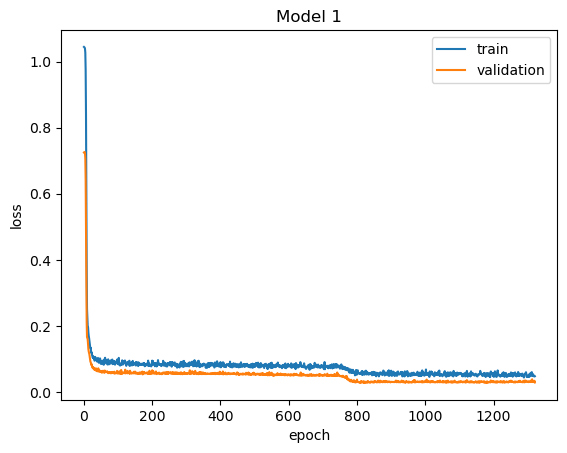

In [22]:
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.title('Model 1')
plt.show()

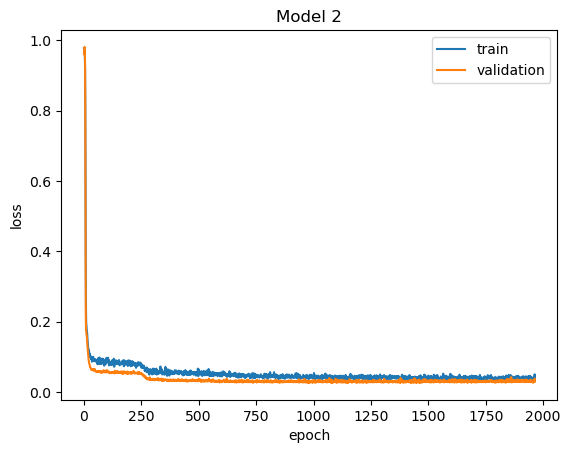

In [23]:
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.title('Model 2')
plt.show()

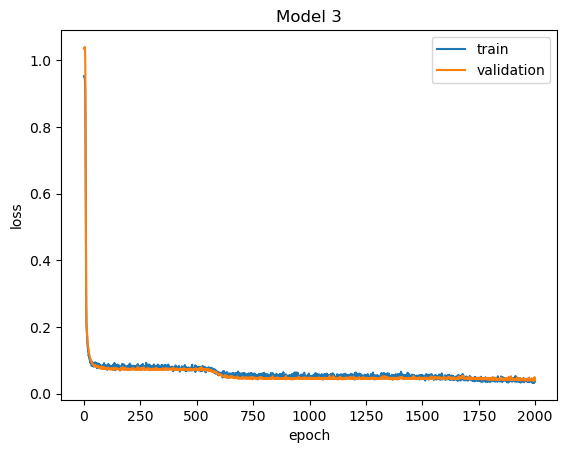

In [24]:
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.title('Model 3')
plt.show()

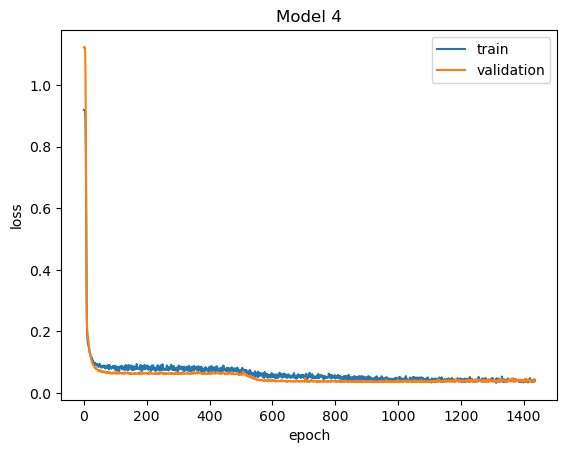

In [25]:
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'])
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper right')
plt.title('Model 4')
plt.show()

### Visualize Predicted vs Observed

In order to do this, we need to load in the data

In [26]:
data_dir = "/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/operational_model/data/"

all_files = pd.Series(os.listdir(data_dir))
validation = all_files[all_files.str.contains('validation')]
training = all_files[all_files.str.contains('training')]

# these files end up in no particular order, so we need to sort them
validation = validation.sort_values()
training = training.sort_values()

def load_data(file):
    return pd.read_csv(os.path.join(data_dir, file), sep=',')

val1 = load_data(validation.values[0])
train1 = load_data(training.values[0])

val2 = load_data(validation.values[1])
train2 = load_data(training.values[1])

val3 = load_data(validation.values[2])
train3 = load_data(training.values[2])

val4 = load_data(validation.values[3])
train4 = load_data(training.values[3])

In [27]:
drop_cols = ['total_solar_radiation_m2', 'mean_rel_hum_m2', 
       'pump_cfs_m2', 'pump_cfs_m3', 'nf_cfs_m2', 'nf_cfs_m3', 'nf_cfs_m4',
       'chipmunk_cfs_m2', 'chipmunk_cfs_m3', 'chipmunk_cfs_m4']

val1 = val1.drop(columns = drop_cols)
train1 = train1.drop(columns = drop_cols)

val2 = val2.drop(columns = drop_cols)
train2 = train2.drop(columns = drop_cols)

val3 = val3.drop(columns = drop_cols)
train3 = train3.drop(columns = drop_cols)

val4 = val4.drop(columns = drop_cols)
train4 = train4.drop(columns = drop_cols)

And then create the feature and lables for training and validation datasets

In [28]:
features1, labels_1, val_features1, val_labels_1 = twotemp_labels_features(train1, val1)
features2, labels_2, val_features2, val_labels_2 = twotemp_labels_features(train2, val2)
features3, labels_3, val_features3, val_labels_3 = twotemp_labels_features(train3, val3)
features4, labels_4, val_features4, val_labels_4 = twotemp_labels_features(train4, val4)

And load the pickle files from the `tiny_model_2y.ipynb` notebook

In [29]:
models = [f for f in os.listdir(model_dir) if 'history' not in f]

model_1 = load_pickle_file(models[0], model_dir)
model_2 = load_pickle_file(models[1], model_dir)
model_3 = load_pickle_file(models[2], model_dir)
model_4 = load_pickle_file(models[3], model_dir)


And then we need to transform the label data back to the original scale. 

In [30]:
transform = pd.read_csv("/Users/steeleb/Documents/GitHub/TLS_DSS/model_submodule/model_dev/data/mu_sigma.csv", index_col=0)
print(transform)

                             mean          sd
parameter                                    
mean_1m_temp_degC       14.994221    2.453251
mean_0_5m_temp_degC     13.386770    2.143041
pump_cfs               174.991848  201.099237
nf_cfs                 153.396052  206.339650
chipmunk_cfs            17.602037   60.058174
mean_air_temp           49.730283    8.996207
max_air_temp            63.312617   11.062407
min_air_temp            36.725728    7.874851
mean_wind                4.271894    1.355502
max_wind                 9.418545    3.119146
min_wind                 1.336486    0.663057
mean_rel_hum            59.884296   14.139012
max_rel_hum             87.455524   11.228093
total_solar_radiation  165.899647   53.077438


In [31]:
t_mean_1m = transform['mean'].get('mean_1m_temp_degC')
t_std_1m = transform['sd'].get('mean_1m_temp_degC')

t_mean_05m = transform['mean'].get('mean_0_5m_temp_degC')
t_std_05m = transform['sd'].get('mean_0_5m_temp_degC')

Now, we'll u se the model to predict the labels for the training and validation datasets using the mean and standard deviations from the preprocessing routine.

In [32]:
# Call predict_values for each dataset
p_train_1m_1, p_train_05m_1, act_train_1m_1, act_train_05m_1, p_val_1m_1, p_val_05m_1, act_val_1m_1, act_val_05m_1 = predict_2_values(model_1, features1, val_features1, labels_1, val_labels_1, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
p_train_1m_2, p_train_05m_2, act_train_1m_2, act_train_05m_2, p_val_1m_2, p_val_05m_2, act_val_1m_2, act_val_05m_2 = predict_2_values(model_2, features2, val_features2, labels_2, val_labels_2, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
p_train_1m_3, p_train_05m_3, act_train_1m_3, act_train_05m_3, p_val_1m_3, p_val_05m_3, act_val_1m_3, act_val_05m_3 = predict_2_values(model_3, features3, val_features3, labels_3, val_labels_3, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)
p_train_1m_4, p_train_05m_4, act_train_1m_4, act_train_05m_4, p_val_1m_4, p_val_05m_4, act_val_1m_4, act_val_05m_4 = predict_2_values(model_4, features4, val_features4, labels_4, val_labels_4, t_mean_1m, t_mean_05m, t_std_1m, t_std_05m)


Finally, we can plot the predicted vs observed values for the training and validation datasets.

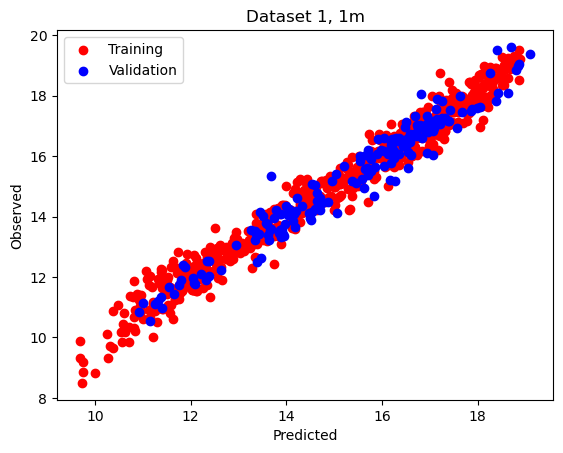

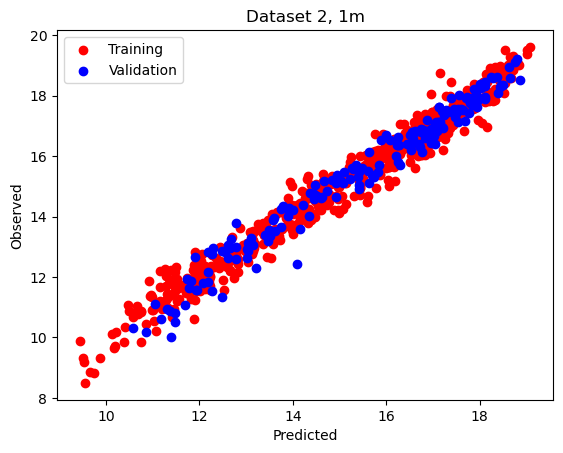

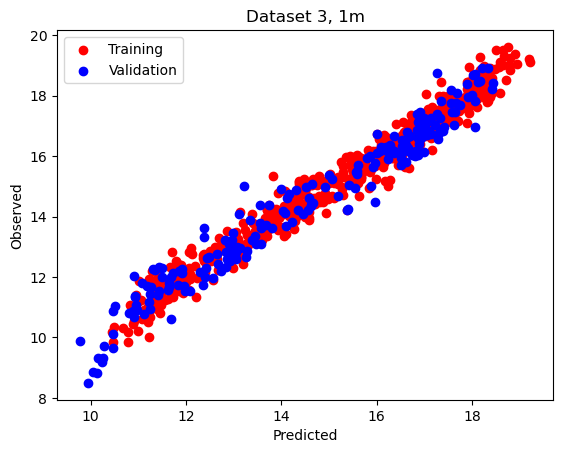

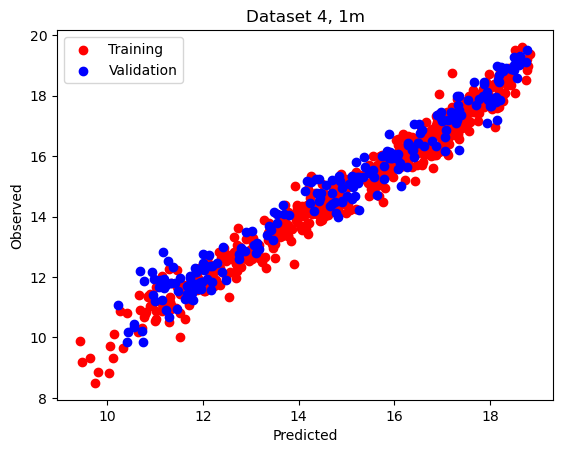

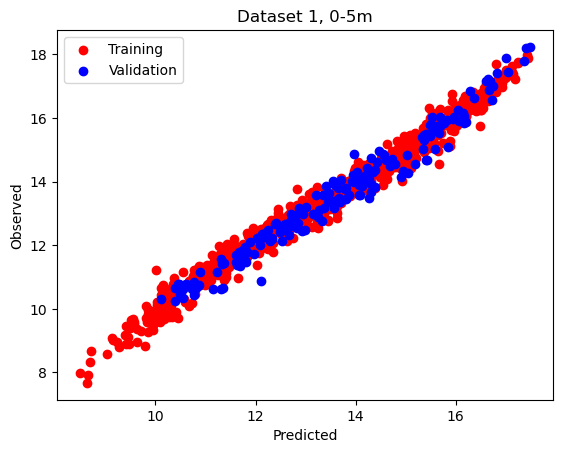

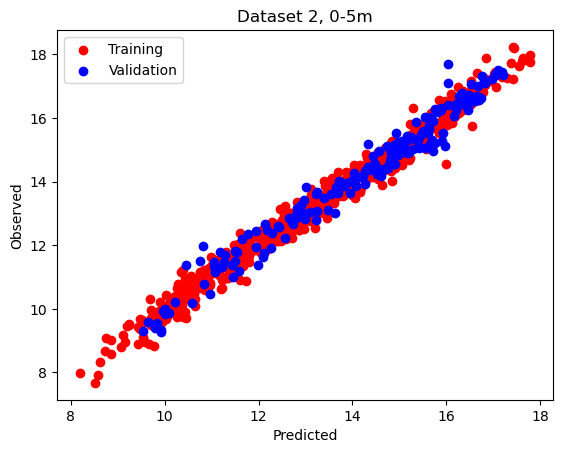

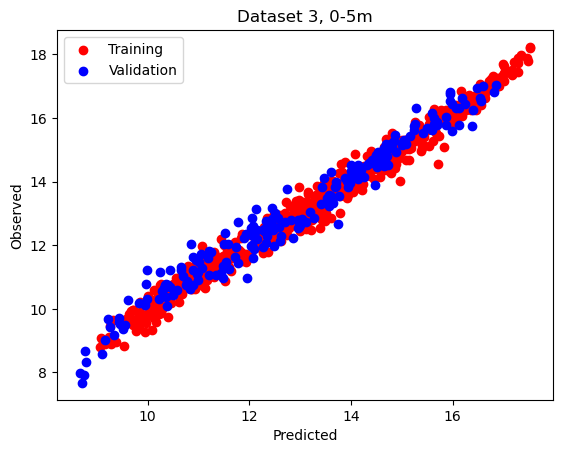

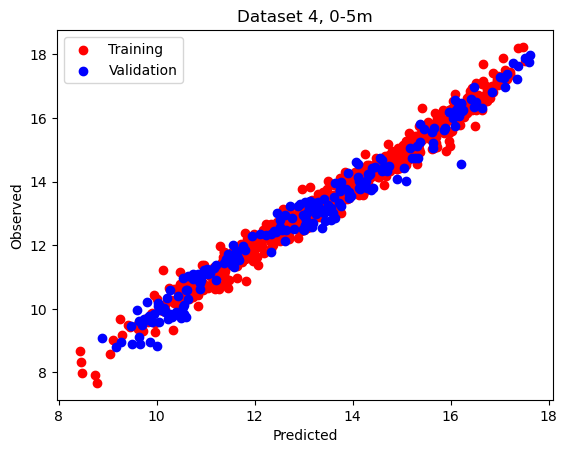

In [33]:
create_scatter_plot('Dataset 1, 1m', p_val_1m_1, act_val_1m_1, p_train_1m_1, act_train_1m_1)
create_scatter_plot('Dataset 2, 1m', p_val_1m_2, act_val_1m_2, p_train_1m_2, act_train_1m_2)
create_scatter_plot('Dataset 3, 1m', p_val_1m_3, act_val_1m_3, p_train_1m_3, act_train_1m_3)
create_scatter_plot('Dataset 4, 1m', p_val_1m_4, act_val_1m_4, p_train_1m_4, act_train_1m_4)


create_scatter_plot('Dataset 1, 0-5m', p_val_05m_1, act_val_05m_1, p_train_05m_1, act_train_05m_1)
create_scatter_plot('Dataset 2, 0-5m', p_val_05m_2, act_val_05m_2, p_train_05m_2, act_train_05m_2)
create_scatter_plot('Dataset 3, 0-5m', p_val_05m_3, act_val_05m_3, p_train_05m_3, act_train_05m_3)
create_scatter_plot('Dataset 4, 0-5m', p_val_05m_4, act_val_05m_4, p_train_05m_4, act_train_05m_4)


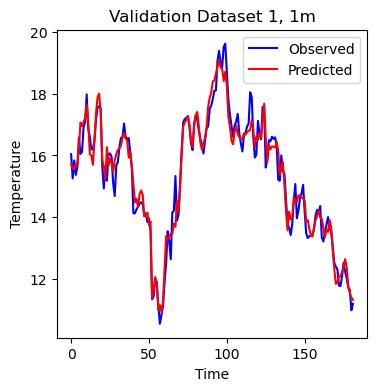

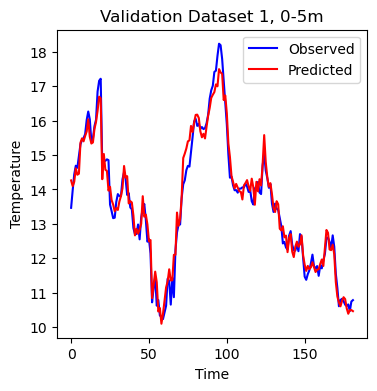

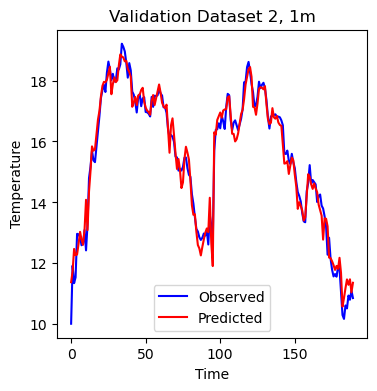

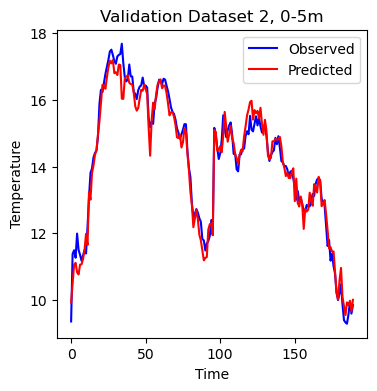

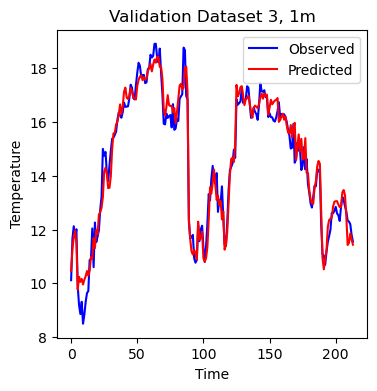

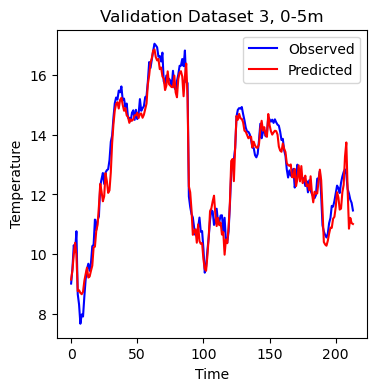

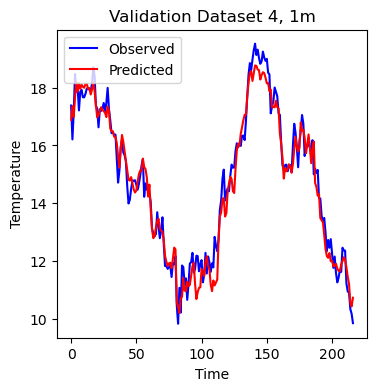

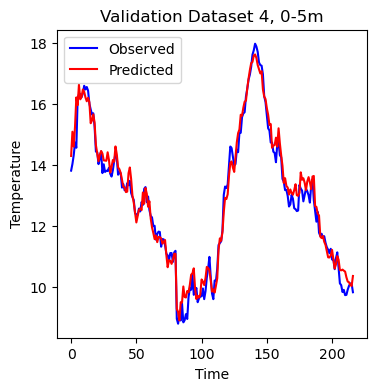

In [34]:
ts_plot(act_val_1m_1, p_val_1m_1, 'Validation Dataset 1, 1m')
ts_plot(act_val_05m_1, p_val_05m_1, 'Validation Dataset 1, 0-5m')
ts_plot(act_val_1m_2, p_val_1m_2, 'Validation Dataset 2, 1m')
ts_plot(act_val_05m_2, p_val_05m_2, 'Validation Dataset 2, 0-5m')
ts_plot(act_val_1m_3, p_val_1m_3, 'Validation Dataset 3, 1m')
ts_plot(act_val_05m_3, p_val_05m_3, 'Validation Dataset 3, 0-5m')
ts_plot(act_val_1m_4, p_val_1m_4, 'Validation Dataset 4, 1m')
ts_plot(act_val_05m_4, p_val_05m_4, 'Validation Dataset 4, 0-5m')


In [35]:
# loop through datasets 1-4 at 1m
for i in range(1, 5):
    act_train_1m = globals()["act_train_1m_" + str(i)]
    pred_train_1m = globals()["p_train_1m_" + str(i)]
    act_val_1m = globals()["act_val_1m_" + str(i)]
    pred_val_1m = globals()["p_val_1m_" + str(i)]
    print_error_metrics(i, act_train_1m, pred_train_1m, act_val_1m, pred_val_1m)


DATASET 1
Mean Squared Error for Training Dataset 1 : 0.18673859526173278
Mean Absolute Error for Training Dataset 1 : 0.342400748162036
Mean Squared Error for Validation Dataset 1 : 0.17641039762633304
Mean Absolute Error for Validation Dataset 1 : 0.3219405442324536
 
DATASET 2
Mean Squared Error for Training Dataset 2 : 0.16564309548517628
Mean Absolute Error for Training Dataset 2 : 0.31307745148134913
Mean Squared Error for Validation Dataset 2 : 0.14450223557684685
Mean Absolute Error for Validation Dataset 2 : 0.2888560713726674
 
DATASET 3
Mean Squared Error for Training Dataset 3 : 0.15644455043332509
Mean Absolute Error for Training Dataset 3 : 0.30756482284306985
Mean Squared Error for Validation Dataset 3 : 0.2690234903851113
Mean Absolute Error for Validation Dataset 3 : 0.39684236175918797
 
DATASET 4
Mean Squared Error for Training Dataset 4 : 0.1715325159376648
Mean Absolute Error for Training Dataset 4 : 0.3171354826659078
Mean Squared Error for Validation Dataset 4 : 

In [36]:
# and a 0-5m
for i in range(1, 5):
    act_train_05m = globals()["act_train_05m_" + str(i)]
    pred_train_05m = globals()["p_train_05m_" + str(i)]
    act_val_05m = globals()["act_val_05m_" + str(i)]
    pred_val_05m = globals()["p_val_05m_" + str(i)]
    print_error_metrics(i, act_train_05m, pred_train_05m, act_val_05m, pred_val_05m)


DATASET 1
Mean Squared Error for Training Dataset 1 : 0.10413330913255997
Mean Absolute Error for Training Dataset 1 : 0.2589665669277359
Mean Squared Error for Validation Dataset 1 : 0.1152171544818537
Mean Absolute Error for Validation Dataset 1 : 0.2610953113380292
 
DATASET 2
Mean Squared Error for Training Dataset 2 : 0.08842776917330794
Mean Absolute Error for Training Dataset 2 : 0.22707691504848407
Mean Squared Error for Validation Dataset 2 : 0.13085119980935678
Mean Absolute Error for Validation Dataset 2 : 0.2733948819284785
 
DATASET 3
Mean Squared Error for Training Dataset 3 : 0.09152104535829388
Mean Absolute Error for Training Dataset 3 : 0.24204583463165266
Mean Squared Error for Validation Dataset 3 : 0.17172658931408002
Mean Absolute Error for Validation Dataset 3 : 0.32695637610848854
 
DATASET 4
Mean Squared Error for Training Dataset 4 : 0.09469666218799946
Mean Absolute Error for Training Dataset 4 : 0.23652942398125262
Mean Squared Error for Validation Dataset 4

Just a quick reminder of the baseline: 

1m baseline

Mean Squared Error for 1m baseline : 0.23

Mean Absolute Error for 1m baseline : 0.38

0-5m baseline

Mean Squared Error for 0-5m baseline : 0.12

Mean Absolute Error for 0-5m baseline : 0.26

Our model absolutely slays. I want to test a smaller network, but this might be a winner! Let's look at the SHAP before that, though.